# DeepST × Moffitt MERFISH — Unified Benchmark
**Author**: Mohammed | Bahçeşehir University – M.Sc. Computer Engineering

### Unified parameters (matched with SpaGCN notebook)
- `SAMPLE_N = 50_000` — same sample cap as SpaGCN
- `N_CLUSTERS = 15` — fixed, matches ground-truth cell types & SpaGCN (was auto-detected before)
- `SEED = 42` — single seed for all randomness
- Silhouette score added alongside ARI / NMI
- Runtime logged per slice (for thesis comparison table)
- Resume-after-crash: already-done slices are skipped on re-run

In [1]:
from google.colab import drive
drive.mount('/content/drive')

print("Copying dataset locally (faster I/O)...")
!cp "/content/drive/MyDrive/Colab Notebooks/Datasets/cells_cleaned.csv" /content/cells_cleaned.csv
print("Done!")

Mounted at /content/drive
Copying dataset locally (faster I/O)...
Done!


In [2]:
import subprocess, re, torch

def run(cmd):
    subprocess.check_call(cmd, shell=True)

tv      = torch.__version__
base    = re.match(r'([\d\.]+)', tv).group(1)
cuda    = re.search(r'(cu\d+)', tv).group(1) if 'cu' in tv else 'cpu'
pyg_url = f'https://data.pyg.org/whl/torch-{base}+{cuda}.html'
print(f'Torch: {tv} | PyG URL: {pyg_url}')

run(f'pip install -q torch_scatter torch_sparse torch_cluster torch_spline_conv -f {pyg_url}')
run('pip install -q torch_geometric==2.3.1')
run('pip install -q deepstkit')
print('Done. RESTART KERNEL NOW.')

Torch: 2.10.0+cu128 | PyG URL: https://data.pyg.org/whl/torch-2.10.0+cu128.html
Done. RESTART KERNEL NOW.


In [3]:
import matplotlib
matplotlib.use('Agg')

import os, gc, time, warnings, traceback
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import torch
import deepstkit as dt
from sklearn.metrics import (adjusted_rand_score,
                              normalized_mutual_info_score,
                              silhouette_score)

sc.settings.verbosity = 0

def save_and_close(path, dpi=120):
    plt.savefig(path, bbox_inches='tight', dpi=dpi)
    plt.close('all')
    gc.collect()

print('Imports OK')

Imports OK


In [4]:
# =============================================================================
# ╔══════════════════════════════════════════╗
# ║           CONTROL PANEL                 ║
# ╚══════════════════════════════════════════╝
# =============================================================================

DATA_PATH   = '/content/cells_cleaned.csv'
RESULTS_DIR = '/content/drive/MyDrive/Colab Notebooks/Datasets/deepst_results_50k'
os.makedirs(RESULTS_DIR, exist_ok=True)

SAMPLE_N    = 50_000    # unified with SpaGCN
N_CLUSTERS  = 15        # unified with SpaGCN — fixed, matches 15 Moffitt cell types
SEED        = 42        # single seed for all randomness

# DeepST-specific hyperparameters (unchanged from official pipeline)
PCA_N_COMPS    = 50
PRE_EPOCHS     = 300
EPOCHS         = 300
SPATIAL_K      = 10     # augmentation neighbours (DeepST default)
NEIGHBOUR_K    = 4      # neighbour aggregation (DeepST default)
ADJACENT_WEIGHT= 0.3    # spatial weight (DeepST default)
GRAPH_K        = 12     # spatial graph neighbours (DeepST default)
RAD_CUTOFF     = 150    # spatial graph radius (DeepST default)

COL_X        = 'Centroid_X'
COL_Y        = 'Centroid_Y'
COL_CELL_ID  = 'Cell_ID'
COL_CELL_TYPE= 'Cell_class'
COL_ANIMAL   = 'Animal_ID'
COL_BREGMA   = 'Bregma'
GENE_START_COL = 9

USE_GPU = torch.cuda.is_available()
print(f'GPU: {USE_GPU}')
print(f'SAMPLE_N    : {SAMPLE_N:,}')
print(f'N_CLUSTERS  : {N_CLUSTERS}')
print(f'SEED        : {SEED}')
print('Config set.')

GPU: True
SAMPLE_N    : 50,000
N_CLUSTERS  : 15
SEED        : 42
Config set.


In [5]:
print('Loading CSV (~1 min)...')
df = pd.read_csv(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} cells × {df.shape[1]} columns')

gene_cols = df.columns[GENE_START_COL:].tolist()
meta_cols = df.columns[:GENE_START_COL].tolist()

bregma_values = sorted(df[COL_BREGMA].unique())
print(f'\nBregma slices ({len(bregma_values)}): {bregma_values}')
print(df[COL_BREGMA].value_counts().sort_index())

Loading CSV (~1 min)...
Loaded: 874,768 cells × 164 columns

Bregma slices (12): [np.float64(-0.29), np.float64(-0.24), np.float64(-0.19), np.float64(-0.14), np.float64(-0.09), np.float64(-0.04), np.float64(0.01), np.float64(0.06), np.float64(0.11), np.float64(0.16), np.float64(0.21), np.float64(0.26)]
Bregma
-0.29     40239
-0.24     36919
-0.19     41766
-0.14     42453
-0.09     40979
-0.04     41778
 0.01     30020
 0.06     29053
 0.11    148714
 0.16    147307
 0.21    138797
 0.26    136743
Name: count, dtype: int64


In [6]:
def run_deepst_on_sample(df_slice, bregma):
    """
    Sample SAMPLE_N cells, run full DeepST pipeline, return metrics.
    N_CLUSTERS is fixed (not auto-detected) to ensure fair comparison with SpaGCN.
    Verified against deepstkit 2.0.3 API (dt.main.run → _get_augment → _get_graph
    → _data_process → _fit → _get_cluster_data).
    """
    tag       = f'bregma_{str(bregma).replace("-", "neg").replace(".", "p")}'
    slice_dir = os.path.join(RESULTS_DIR, tag)
    os.makedirs(slice_dir, exist_ok=True)

    # ── Random sample ─────────────────────────────────────────────────────────
    n_available = len(df_slice)
    n_sample    = min(SAMPLE_N, n_available)
    df_sample   = df_slice.sample(n=n_sample, random_state=SEED).reset_index(drop=True)
    print(f'  Sampled {n_sample:,} / {n_available:,} cells')

    # ── Build AnnData ─────────────────────────────────────────────────────────
    X   = df_sample[gene_cols].values.astype(np.float32)
    obs = df_sample[meta_cols].copy()
    if COL_CELL_ID in obs.columns:
        obs.index = obs[COL_CELL_ID].astype(str)

    adata = ad.AnnData(X=X, obs=obs, var=pd.DataFrame(index=gene_cols))
    adata.obsm['spatial'] = df_sample[[COL_X, COL_Y]].values.astype(np.float64)

    # ── Light QC ──────────────────────────────────────────────────────────────
    adata.layers['raw_counts'] = adata.X.copy()
    sc.pp.filter_cells(adata, min_genes=5)
    sc.pp.filter_cells(adata, min_counts=1)
    sc.pp.filter_genes(adata, min_cells=3)

    # N_CLUSTERS fixed to 15 — unified with SpaGCN (not auto-detected from sample)
    n_domains = N_CLUSTERS

    # ── PCA guard ─────────────────────────────────────────────────────────────
    safe_pca = min(PCA_N_COMPS, adata.n_vars - 1, adata.n_obs - 1)

    # ── DeepST pipeline (official deepstkit API) ───────────────────────────────
    dt.utils_func.seed_torch(seed=SEED)

    deepst = dt.main.run(
        save_path  = slice_dir,
        task       = 'Identify_Domain',
        pre_epochs = PRE_EPOCHS,
        epochs     = EPOCHS,
        use_gpu    = USE_GPU
    )

    adata = deepst._get_augment(
        adata,
        spatial_type      = 'BallTree',
        use_morphological = False,
        use_data          = 'raw',
        spatial_k         = SPATIAL_K,
        neighbour_k       = NEIGHBOUR_K,
        adjacent_weight   = ADJACENT_WEIGHT,
    )

    graph_dict = deepst._get_graph(
        adata.obsm['spatial'],
        distType   = 'BallTree',
        k          = GRAPH_K,
        rad_cutoff = RAD_CUTOFF,
    )

    data         = deepst._data_process(adata, pca_n_comps=safe_pca)
    deepst_embed = deepst._fit(data=data, graph_dict=graph_dict)
    adata.obsm['DeepST_embed'] = deepst_embed

    adata = deepst._get_cluster_data(
        adata,
        n_domains = n_domains,
        priori    = True,
        shape     = 'square',
    )

    # ── Metrics ───────────────────────────────────────────────────────────────
    ari, nmi, sil = np.nan, np.nan, np.nan
    if COL_CELL_TYPE in adata.obs.columns:
        true_labels = adata.obs[COL_CELL_TYPE].astype(str).tolist()
        pred_labels = adata.obs['DeepST_refine_domain'].astype(str).tolist()

        ari = adjusted_rand_score(true_labels, pred_labels)
        nmi = normalized_mutual_info_score(true_labels, pred_labels,
                                           average_method='arithmetic')
        try:
            if len(set(pred_labels)) > 1:
                sil = silhouette_score(
                    adata.obsm['DeepST_embed'], pred_labels,
                    sample_size=min(5000, len(pred_labels)),
                    random_state=SEED
                )
        except Exception:
            pass

    # ── Spatial plot ──────────────────────────────────────────────────────────
    palette = matplotlib.colormaps.get_cmap('tab10')
    fig, ax = plt.subplots(figsize=(7, 7))
    labels  = adata.obs['DeepST_refine_domain'].astype('category')
    cats    = labels.cat.categories.tolist()
    for idx, label in enumerate(cats):
        mask = (labels == label).values
        ax.scatter(adata.obsm['spatial'][mask, 0], adata.obsm['spatial'][mask, 1],
                   s=3, alpha=0.7, label=str(label),
                   color=palette(idx / max(len(cats) - 1, 1)))
    ax.set_title(f'DeepST — Bregma {bregma} (n={n_sample})', fontsize=11)
    ax.set_aspect('equal')
    ax.legend(markerscale=4, fontsize=7)
    save_and_close(os.path.join(slice_dir, 'spatial_domains.png'))

    # ── Save per-slice assignments ────────────────────────────────────────────
    save_cols = ['DeepST_domain', 'DeepST_refine_domain']
    if COL_CELL_TYPE in adata.obs.columns:
        save_cols.append(COL_CELL_TYPE)
    adata.obs[save_cols].to_csv(os.path.join(slice_dir, 'cell_domains.csv'))

    result = {
        'Bregma'    : bregma,
        'n_total'   : n_available,
        'n_sampled' : n_sample,
        'n_domains' : n_domains,
        'ARI'       : round(float(ari), 4),
        'NMI'       : round(float(nmi), 4),
        'Silhouette': round(float(sil), 4),
    }

    # ── Full memory cleanup ───────────────────────────────────────────────────
    del adata, deepst, data, deepst_embed, graph_dict, df_sample, X, obs
    gc.collect()
    if USE_GPU:
        torch.cuda.empty_cache()

    return result

print('Helper function ready.')

Helper function ready.


In [7]:
# =============================================================================
# Run all slices — safe loop with resume-after-crash
# =============================================================================

RESULTS_CSV = os.path.join(RESULTS_DIR, 'deepst_allslices_metrics.csv')

if os.path.exists(RESULTS_CSV):
    done_df      = pd.read_csv(RESULTS_CSV)
    all_results  = done_df.to_dict('records')
    done_bregmas = set(done_df['Bregma'].tolist())
    print(f'Resuming — {len(done_bregmas)} slices already done: {sorted(done_bregmas)}')
else:
    all_results  = []
    done_bregmas = set()
    print('Starting fresh.')

failed        = []
n_total_slices = len(bregma_values)
pipeline_start = time.time()

for i, bregma in enumerate(bregma_values):

    if bregma in done_bregmas:
        print(f'[{i+1}/{n_total_slices}] Bregma={bregma} — already done, skipping.')
        continue

    n_total = (df[COL_BREGMA] == bregma).sum()
    print(f'\n[{i+1}/{n_total_slices}] Bregma={bregma} | Total cells={n_total:,} | Sampling {SAMPLE_N}')

    df_slice    = df[df[COL_BREGMA] == bregma].copy().reset_index(drop=True)
    slice_start = time.time()

    try:
        result = run_deepst_on_sample(df_slice=df_slice, bregma=bregma)
        slice_time = time.time() - slice_start
        result['time_min'] = round(slice_time / 60, 2)

        all_results.append(result)
        done_bregmas.add(bregma)
        pd.DataFrame(all_results).to_csv(RESULTS_CSV, index=False)
        print(f'  ✅ ARI={result["ARI"]:.4f} | NMI={result["NMI"]:.4f} | '
              f'Sil={result["Silhouette"]:.4f} | {slice_time/60:.1f} min — saved')

    except Exception as e:
        slice_time = time.time() - slice_start
        print(f'  ❌ Bregma={bregma} failed: {e}')
        traceback.print_exc()
        failed.append({'Bregma': bregma, 'error': str(e)})
        gc.collect()
        if USE_GPU:
            torch.cuda.empty_cache()

    finally:
        del df_slice
        gc.collect()

total_time = time.time() - pipeline_start
print(f'\n✓ Loop finished. {len(all_results)} slices done, {len(failed)} failed.')
print(f'  Total pipeline time: {total_time/60:.1f} min ({total_time/3600:.1f} h)')
if failed:
    print('Failed:', failed)

Starting fresh.

[1/12] Bregma=-0.29 | Total cells=40,239 | Sampling 50000
  Sampled 40,239 / 40,239 cells
Spatial weights calculated. Average neighbors: 10.0
Gene expression weights calculated.
Final weight matrix calculated and stored in adata.obsm['weights_matrix_all']


Finding adjacent spots: 100%|██████████ [ time left: 00:00 ]


Step 1: Data augmentation completed
12.0000 neighbors per cell on average.
Step 2: Spatial graph computation completed
Running DeepST analysis...


Pretraining initial model: 100%|██████████ [ time left: 00:00 ]
Training final model: 100%|██████████ [ time left: 00:00 ]


Step 3: DeepST training completed
Memory usage: 22.45 GB
Total time: 3.24 minutes
Analysis completed successfully
Found resolution: 0.71 for 15 domains
  ✅ ARI=0.3208 | NMI=0.5150 | Sil=0.1996 | 18.0 min — saved

[2/12] Bregma=-0.24 | Total cells=36,919 | Sampling 50000
  Sampled 36,919 / 36,919 cells
Spatial weights calculated. Average neighbors: 10.0
Gene expression weights calculated.
Final weight matrix calculated and stored in adata.obsm['weights_matrix_all']


...

Step 3: DeepST training completed
Memory usage: 32.93 GB
Total time: 3.00 minutes
Analysis completed successfully
Found resolution: 0.71 for 15 domains
  ✅ ARI=0.3066 | NMI=0.5025 | Sil=0.1506 | 22.1 min — saved

[12/12] Bregma=0.26 | Total cells=136,743 | Sampling 50000
  Sampled 50,000 / 136,743 cells
Spatial weights calculated. Average neighbors: 10.0
Gene expression weights calculated.
Final weight matrix calculated and stored in adata.obsm['weights_matrix_all']


Finding adjacent spots: 100%|██████████ [ time left: 00:00 ]


Step 1: Data augmentation completed
12.0000 neighbors per cell on average.
Step 2: Spatial graph computation completed
Running DeepST analysis...


Pretraining initial model: 100%|██████████ [ time left: 00:00 ]
Training final model: 100%|██████████ [ time left: 00:00 ]


Step 3: DeepST training completed
Memory usage: 33.05 GB
Total time: 2.88 minutes
Analysis completed successfully
Found resolution: 0.66 for 15 domains
  ✅ ARI=0.3601 | NMI=0.5347 | Sil=0.1522 | 22.2 min — saved

✓ Loop finished. 12 slices done, 0 failed.
  Total pipeline time: 207.6 min (3.5 h)


In [8]:
# =============================================================================
# Final summary
# =============================================================================

results_df = pd.read_csv(RESULTS_CSV)

print('=' * 60)
print('  DeepST — Moffitt MERFISH — All Bregma Slices')
print('=' * 60)
print(results_df[['Bregma','n_total','n_sampled','n_domains',
                   'ARI','NMI','Silhouette','time_min']].to_string(index=False))
print('=' * 60)
print(f'  Mean ARI        : {results_df["ARI"].mean():.4f} ± {results_df["ARI"].std():.4f}')
print(f'  Mean NMI        : {results_df["NMI"].mean():.4f} ± {results_df["NMI"].std():.4f}')
print(f'  Mean Silhouette : {results_df["Silhouette"].mean():.4f} ± {results_df["Silhouette"].std():.4f}')
print(f'  Min/Max ARI     : {results_df["ARI"].min():.4f} / {results_df["ARI"].max():.4f}')
print(f'  Min/Max NMI     : {results_df["NMI"].min():.4f} / {results_df["NMI"].max():.4f}')
print(f'  Total time      : {results_df["time_min"].sum():.1f} min')
print('=' * 60)

thesis = pd.DataFrame([{
    'Method'          : 'DeepST',
    'Dataset'         : 'Moffitt_MERFISH',
    'Slices'          : len(results_df),
    'Cells_per_slice' : SAMPLE_N,
    'N_clusters'      : N_CLUSTERS,
    'Seed'            : SEED,
    'Mean_ARI'        : round(results_df['ARI'].mean(), 4),
    'Std_ARI'         : round(results_df['ARI'].std(),  4),
    'Mean_NMI'        : round(results_df['NMI'].mean(), 4),
    'Std_NMI'         : round(results_df['NMI'].std(),  4),
    'Mean_Silhouette' : round(results_df['Silhouette'].mean(), 4),
    'Total_time_min'  : round(results_df['time_min'].sum(), 2),
    'PCA_comps'       : PCA_N_COMPS,
    'pre_epochs'      : PRE_EPOCHS,
    'epochs'          : EPOCHS,
}])
thesis.to_csv(os.path.join(RESULTS_DIR, 'deepst_thesis_summary.csv'), index=False)
print('\nThesis summary saved: deepst_thesis_summary.csv')
print(thesis.to_string(index=False))

  DeepST — Moffitt MERFISH — All Bregma Slices
 Bregma  n_total  n_sampled  n_domains    ARI    NMI  Silhouette  time_min
  -0.29    40239      40239         15 0.3208 0.5150      0.1996     18.03
  -0.24    36919      36919         15 0.3063 0.4969      0.1953     14.88
  -0.19    41766      41766         15 0.2976 0.4897      0.1902     16.02
  -0.14    42453      42453         15 0.3188 0.4826      0.2016     18.06
  -0.09    40979      40979         15 0.3179 0.4923      0.1982     16.43
  -0.04    41778      41778         15 0.2699 0.4843      0.2003     16.18
   0.01    30020      30020         15 0.3851 0.5356      0.2261      9.57
   0.06    29053      29053         15 0.4030 0.5440      0.2538      9.80
   0.11   148714      50000         15 0.2887 0.4526      0.1096     22.15
   0.16   147307      50000         15 0.3819 0.4999      0.0943     22.12
   0.21   138797      50000         15 0.3066 0.5025      0.1506     22.08
   0.26   136743      50000         15 0.3601 0.5347 

In [22]:
results_df = pd.read_csv(RESULTS_CSV)
x = [str(b) for b in results_df['Bregma']]
n_cells = results_df['n_sampled'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, color in [
    (axes[0], 'ARI',        'steelblue'),
    (axes[1], 'NMI',        'coral'),
    (axes[2], 'Silhouette', 'seagreen'),
]:
    bars = ax.bar(x, results_df[metric], color=color, edgecolor='white')
    mean_val = results_df[metric].mean()
    std_val  = results_df[metric].std()
    ax.axhline(mean_val, color='red', linestyle='--',
               label=f'Mean={mean_val:.4f} ± {std_val:.4f}')

    for bar, val, n in zip(bars, results_df[metric], n_cells):
        # metric value on top of bar
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
        # cell count inside bar at bottom in white
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.05,
                f'{n:,}', ha='center', va='bottom', fontsize=7, color='black')

    ax.set_xticks(range(len(x)))
    ax.set_xticklabels(x, fontsize=8, rotation=45)
    ax.set_title(f'{metric} per Bregma slice', fontsize=12)
    ax.set_xlabel('Bregma', fontsize=9)
    ax.set_ylabel(metric)
    ax.set_ylim(0, results_df[metric].max() * 1.25)
    ax.legend(fontsize=9)

plt.suptitle('DeepST × Moffitt MERFISH — Performance Across All Bregma Slices',
             fontsize=12, y=1.02)
plt.tight_layout()
save_and_close(os.path.join(RESULTS_DIR, 'allslices_metrics.png'), dpi=180)
print('Chart saved: allslices_metrics.png')

Chart saved: allslices_metrics.png


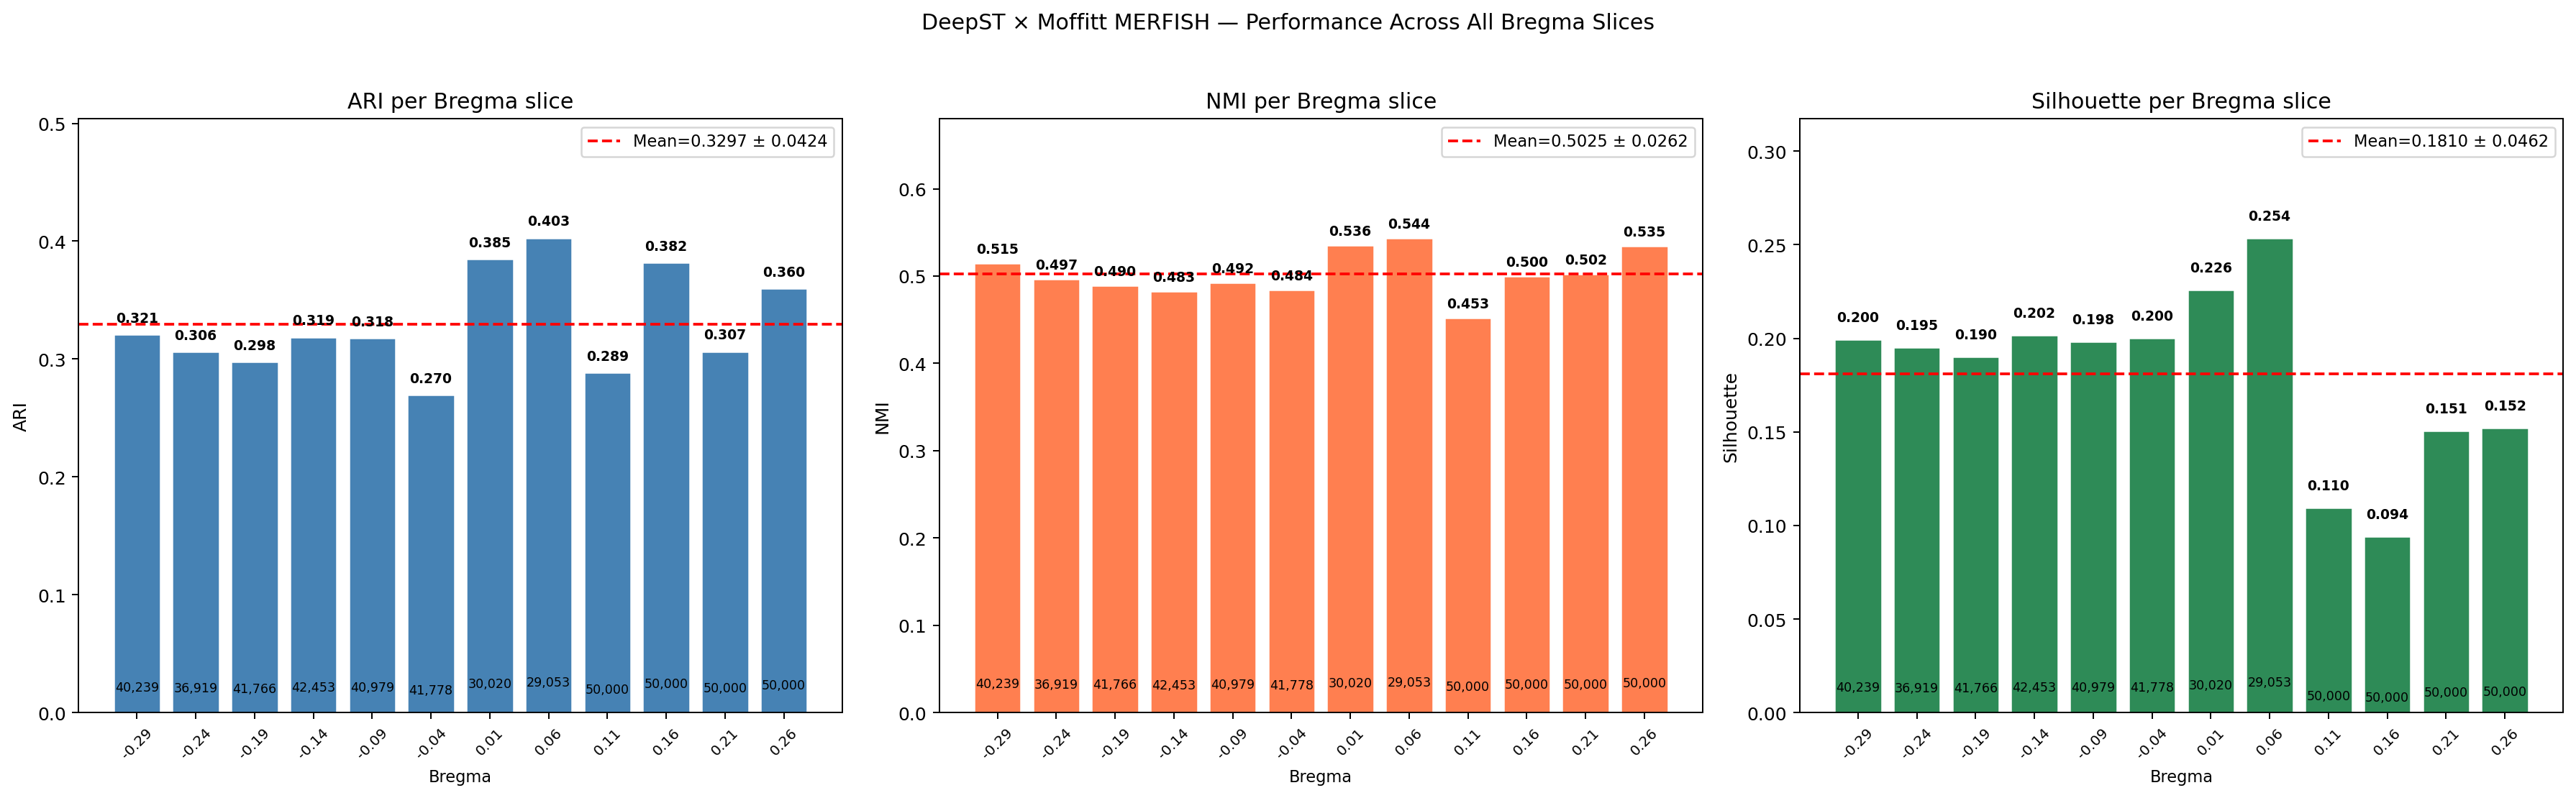

In [23]:
from IPython.display import Image
Image('/content/drive/MyDrive/Colab Notebooks/Datasets/deepst_results_50k/allslices_metrics.png')